# **Laboratorio 1**

---

### Lucía Coudet, Cecilia Waksman

---

# Carga de librerías y verificado de versiones (Python 3.12 y scikit-learn 1.9)

In [295]:
%pip install scikit-learn==1.9.0

^C
Note: you may need to restart the kernel to use updated packages.


In [322]:
import numpy as np
import pandas as pd
import sklearn
import sklearn.preprocessing
import sklearn.feature_selection
pd.options.mode.chained_assignment ='warn' # default='warn'
import graphviz

In [323]:
import sys

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.3 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:42:21) [MSC v.1916 64 bit (AMD64)]
scikit-learn: 1.9.0


# Carga y visualización del dataset

In [324]:
#Leemos los datos
#En https://github.com/schochastics/football-data está el repo original con los datos completos y la documnetación
datos=pd.read_csv('futbol_uruguayo.csv')
datos.head(2)

,home,away,date,gh,ga,full_time,competition,home_ident,away_ident,home_country,away_country,home_code,away_code,home_continent,away_continent,continent,level
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,uruguay,Bella Vista (Uruguay),Defensor Sporting (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,uruguay,CA Penarol (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national


In [325]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15207 entries, 0 to 15206
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   home            15207 non-null  str    
 1   away            15207 non-null  str    
 2   date            15207 non-null  str    
 3   gh              15207 non-null  float64
 4   ga              15207 non-null  float64
 5   full_time       15207 non-null  str    
 6   competition     15207 non-null  str    
 7   home_ident      15207 non-null  str    
 8   away_ident      15207 non-null  str    
 9   home_country    15207 non-null  str    
 10  away_country    15207 non-null  str    
 11  home_code       15207 non-null  str    
 12  away_code       15207 non-null  str    
 13  home_continent  15207 non-null  str    
 14  away_continent  15207 non-null  str    
 15  continent       15207 non-null  str    
 16  level           15207 non-null  str    
dtypes: float64(2), str(15)
memory usage: 2.0 M

---

# 1. PREPROCESAMIENTO

## - Definimos tipo de los atributos

## - Eliminamos variables que cuentan con 1 solo valor (Uruguay, UY, South America, national) y variables **repetidas**

In [300]:
atributos = pd.DataFrame(datos)
print(atributos.nunique())

home                38
away                38
date              3816
gh                  11
ga                  10
full_time            3
competition          1
home_ident          38
away_ident          38
home_country         1
away_country         1
home_code            1
away_code            1
home_continent       1
away_continent       1
continent            1
level                1
dtype: int64


In [301]:
# Verificamos que solo cuenta con valores enteros
print(datos['gh'].unique())
print(datos['ga'].unique())
print(datos["full_time"].unique()) # El partido terminó: F = en los 90 minutos reglamentarios, E	= en tiempo extra/prórroga, P	= mediante definición por penales

[ 1.  3.  2.  6.  4.  7.  0.  5.  8. 10.  9.]
[2. 1. 0. 3. 4. 5. 6. 7. 8. 9.]
<StringArray>
['F', 'P', 'E']
Length: 3, dtype: str


In [326]:
# Verificamos que los atributos identificadores de home y away no agregan información extra, ya que toman los mismos valores
pd.DataFrame({
    'home': datos['home'].unique(),
    'home_ident': datos['home_ident'].unique(),
    'away': datos['away'].unique(),
    'away_ident': datos['away_ident'].unique()
})

,home,home_ident,away,away_ident
0,Bella Vista,Bella Vista (Uruguay),Defensor Sporting,Defensor Sporting (Uruguay)
1,CA Penarol,CA Penarol (Uruguay),River Plate,River Plate (Uruguay)
2,Montevideo Wanderers,Montevideo Wanderers (Uruguay),Racing Club,Racing Club (Uruguay)
3,Central Espanol,Central Espanol (Uruguay),Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay)
4,Nacional,Nacional (Uruguay),Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay)
5,Defensor Sporting,Defensor Sporting (Uruguay),Bella Vista,Bella Vista (Uruguay)
6,Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay),Central Espanol,Central Espanol (Uruguay)
7,Racing Club,Racing Club (Uruguay),Nacional,Nacional (Uruguay)
8,River Plate,River Plate (Uruguay),Montevideo Wanderers,Montevideo Wanderers (Uruguay)
9,Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay),CA Penarol,CA Penarol (Uruguay)


In [327]:
# Categóricos
datos["home"] = datos["home"].astype("category")
datos["away"] = datos["away"].astype("category")
datos["full_time"] =datos["full_time"].astype("category")

# Fechas
datos["date"] = pd.to_datetime(datos["date"])

# Numericos tipo float a enteros
datos["gh"] = datos["gh"].astype(int)
datos["ga"] = datos["ga"].astype(int)

datos = datos.drop(columns=['competition',
                            'home_ident',
                            'away_ident',
                            'home_country',
                            'away_country',
                            'home_code',
                            'away_code',
                            'home_continent',
                            'away_continent',
                            'continent',
                            'level'])

## - Creamos la variable de salida "resultado"



In [328]:
# CREAMOS LA VARIABLE DE SALIDA "RESULTADO"

# Definimos las condiciones
condiciones = [
    datos["gh"] > datos["ga"],  # Gana el local
    datos["gh"] < datos["ga"],  # Gana el visitante
]

# Definimos los resultados para cada condición
opciones = ["L", "V"] # "gana el local", "gana el visitante"

# Aplicamos las condiciones; si no se cumple ninguna (son iguales), asigna "hay empate"
datos["resultado"] = np.select(condiciones, opciones, default="E") # "hay empate"

datos["resultado"] = datos["resultado"].astype("category")

# Ejemplo de visualización
datos[["gh", "ga", "resultado"]].head(2)

,gh,ga,resultado
0,1,2,V
1,1,1,E


## - Eliminamos filas diplicadas
## - Detectamos datos faltantes (no hay)

In [329]:
# ELIMINAMOS FILAS DUPLICADAS
cant_duplicados = datos.duplicated().sum()
print(f"Filas duplicadas encontradas: {cant_duplicados}")
datos = datos.drop_duplicates()

# DETECTAMOS DATOS FALTANTES E IMPUTAMOS MEDIA

print("\nValores faltantes por columna:")
print(datos.isnull().sum())

# Seleccionar columnas numéricas e imputar la media si existen valores nulos

# columnas_numericas = datos.select_dtypes(include=["number"]).columns
# for col in columnas_numericas:
#     if datos[col].isnull().sum() > 0:
#         media_col = datos[col].mean()
#         datos[col] = datos[col].fillna(media_col)
#         print(f"Se imputó la media ({media_col:.2f}) en la columna '{col}'")

Filas duplicadas encontradas: 1

Valores faltantes por columna:
home         0
away         0
date         0
gh           0
ga           0
full_time    0
resultado    0
dtype: int64


## - Creamos nuevos atributos a partir de "date"
## - Eliminamos atributos que tengan información sobre el resultado

In [331]:
# Creamos nuevos atributos para usar en el algoritmo a partir del atributo fecha

# Extraer componentes temporales relevantes:

# Año (para capturar tendencias históricas, ej: evolución del fútbol con las décadas)
datos["year"] = datos["date"].dt.year

# Mes y Trimestre (para capturar estacionalidad en el torneo)
datos["month"] = datos["date"].dt.month

# Día de la semana (0=Lunes, 6=Domingo; útil para ver si se juega fin de semana o entre semana)
datos["dayofweek"] = datos["date"].dt.dayofweek

# Indicador de si es fin de semana (1 si es Sábado/Domingo, 0 si no)
datos["is_weekend"] = datos["dayofweek"].isin([5, 6]).astype(int)

datos = datos.drop(columns=['date', 'gh', 'ga'])

datos.head(2)

,home,away,full_time,resultado,year,month,dayofweek,is_weekend
0,Bella Vista,Defensor Sporting,F,V,1932,3,5,1
1,CA Penarol,River Plate,F,E,1932,3,5,1


In [307]:
datos.info()

<class 'pandas.DataFrame'>
Index: 15206 entries, 0 to 15206
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   home        15206 non-null  category
 1   away        15206 non-null  category
 2   full_time   15206 non-null  category
 3   resultado   15206 non-null  category
 4   year        15206 non-null  int32   
 5   month       15206 non-null  int32   
 6   dayofweek   15206 non-null  int32   
 7   is_weekend  15206 non-null  int64   
dtypes: category(4), int32(3), int64(1)
memory usage: 476.0 KB


In [332]:

# 1. Asegurar el orden cronológico del DataFrame usando las columnas de fecha disponibles
datos = datos.sort_values(by=["year", "month", "dayofweek"]).reset_index(drop=True)

# 2. Descomponer en registros individuales para equipo local y visitante
home_df = datos[['home', 'resultado']].rename(columns={'home': 'equipo'})
home_df['ganado'] = (home_df['resultado'] == 'L').astype(int)

away_df = datos[['away', 'resultado']].rename(columns={'away': 'equipo'})
away_df['ganado'] = (away_df['resultado'] == 'V').astype(int)

# Unir ambos bloques manteniendo el orden
historial = pd.concat([home_df, away_df])

# 3. Calcular la tasa de victorias móvil de los últimos N partidos (ejemplo: N = 5)
N = 5
historial['tasa_victorias'] = (
    historial.groupby('equipo')['ganado']
    .transform(lambda x: x.shift(1).rolling(window=N, min_periods=1).mean())
).fillna(0)

# 4. Asignar las tasas calculadas directamente al DataFrame 'datos'
datos['home_tasa_victorias'] = historial['tasa_victorias'].iloc[:len(datos)].values
datos['away_tasa_victorias'] = historial['tasa_victorias'].iloc[len(datos):].values

# Verificación de las variables agregadas
print(datos[['home', 'away', 'year', 'resultado', 'home_tasa_victorias', 'away_tasa_victorias']].tail(10))


                    home                  away  year resultado  \
15196        CA Juventud           Racing Club  2025         L   
15197           Nacional          Boston River  2025         L   
15198        River Plate            CA Penarol  2025         V   
15199        River Plate             Liverpool  2025         L   
15200        Racing Club           CA Progreso  2025         L   
15201         CA Penarol  Montevideo Wanderers  2025         L   
15202  Defensor Sporting              CA Cerro  2025         L   
15203        CA Juventud           CA Progreso  2025         L   
15204        Racing Club             Torque FC  2025         E   
15205           Nacional               Danubio  2025         L   

       home_tasa_victorias  away_tasa_victorias  
15196                  1.0                  0.6  
15197                  1.0                  0.2  
15198                  0.4                  0.6  
15199                  0.4                  0.2  
15200                  

In [333]:
#Verificamos que las fechas de los partidos se encuentren dentro del rango esperado (1932-2025)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


class ValidadorRangoAnioNum(BaseEstimator, TransformerMixin):
    """Transformador que valida que una o varias columnas con valores numéricos de año

    estén dentro del rango especificado [anio_min, anio_max].
    """

    def __init__(
        self,
        columnas_anio,
        anio_min=1932,
        anio_max=2032,
        lanzar_error=False,
    ):
        self.columnas_anio = columnas_anio
        self.anio_min = anio_min
        self.anio_max = anio_max
        self.lanzar_error = lanzar_error

    def fit(self, X, y=None):
        return self  # No requiere aprendizaje

    def transform(self, X):
        X_copy = X.copy()

        for col in self.columnas_anio:
            años = X_copy[col]

            # Filtrar valores fuera del rango o nulos
            invalidos = X_copy[
                (años < self.anio_min) | (años > self.anio_max) | años.isna()
            ]

            if not invalidos.empty:
                mensaje = (
                    f"⚠️ Se encontraron {len(invalidos)} registros fuera del "
                    f"rango ({self.anio_min} - {self.anio_max}) en la columna '{col}'."
                )
                if self.lanzar_error:
                    raise ValueError(mensaje)
                else:
                    print(mensaje)
                    print(invalidos[[col]])

        return X_copy


# ---------------------------------------------------------

# Definimos el pipeline
pipeline_validacion = Pipeline(
    [
        (
            "validador_anio",
            ValidadorRangoAnioNum(
                columnas_anio=["year"],
                anio_min=1932,
                anio_max=2025,
                lanzar_error=False,  # Cambiar a True para detener el script ante anomalías
            ),
        )
    ]
)

# Ejecutar el pipeline
datos = pipeline_validacion.fit_transform(datos)

In [267]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 15206 entries, 0 to 15205
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   home                 15206 non-null  category
 1   away                 15206 non-null  category
 2   full_time            15206 non-null  category
 3   resultado            15206 non-null  category
 4   year                 15206 non-null  int32   
 5   month                15206 non-null  int32   
 6   dayofweek            15206 non-null  int32   
 7   is_weekend           15206 non-null  int64   
 8   home_tasa_victorias  15206 non-null  float64 
 9   away_tasa_victorias  15206 non-null  float64 
dtypes: category(4), float64(2), int32(3), int64(1)
memory usage: 595.0 KB


---

# 2. MODELOS SUPERVISADOS

Dudas y comentarios:  ⁠
- La partición de los datos que se aplicó toma en cuenta la temporalidad? Tendríamos que implementarlo más explícito con el atributo 'year'? CAMBIADO
- Misma partición que se indica en parte 3? 2024 y 2025 para test. CAMBIADO USANDO 80/20
---
- No entendí la diferencia entre la parte 2 y la 3. El tuneo?
- Cuáles serían los modelos "suyos" que dice la letra?
---
- Para el Árbol yo implementaría OneHot y para el CategoricalNB OrdinalEncoder (pasar categorías a enteros)
- Revisar warning en métricas del árbol: no está prediciendo en ningún caso uno de las categorías de respuesta. No implica que esté mal.
- En el foro vi que habría que implementar Features Selection para ver qué atributos usamos. No sé si en ambas partes y si los mismos atributos
- En el NB el "m" no es exactamente lo mismo que "alpha", pero parecido. Supongo que está bien que usemos ese hiperparámetro.
---
- Hay un .ipynb subido donde van las ppt de Metodología para la clasificación. Ahí implementan un pipeline para todo el proceso. Planeo usar eso en la parte 3.

In [340]:
from sklearn.model_selection import train_test_split

# se particiona los datos en X y Y

# 1. Ordenamos por fecha cronológicamente
#datos = datos.sort_values(by=["year", "month", "dayofweek"]).reset_index(
 #   drop=True
#)

# 2. Separamos la variable objetivo
#datos_y = datos[["resultado"]]

# 3. Eliminamos la variable 'year' de las predictoras
#datos_x = datos.drop(columns=["resultado"])


# 4. Dividimos respetando la temporalidad (sin mezclar)
#X_train, X_test, y_train, y_test = train_test_split(
 #   datos_x, datos_y, test_size=0.2, shuffle=False
#)

import pandas as pd

# 1. Ordenar por fecha cronológicamente
datos = datos.sort_values(by=["year", "month", "dayofweek"]).reset_index(
    drop=True
)

# 2. Separar características (X) conservando temporalmente la columna 'year'
datos_x = datos.drop(columns=["resultado"])
datos_y = datos[["resultado"]]  # 
# 3. Crear máscaras booleanas para la partición por años
mask_train = datos_x["year"] <= 2023
mask_test = datos_x["year"].isin([2024, 2025])

# 4. Dividir los conjuntos de datos según los años
X_train = datos_x[mask_train].copy()
X_test = datos_x[mask_test].copy()

y_train = datos_y[mask_train].copy()
y_test = datos_y[mask_test].copy()

# 5. Eliminar la columna 'year' de los conjuntos de características
#X_train = X_train.drop(columns=["year"]) no lo hago, lo elimino luego en el encoder
#X_test = X_test.drop(columns=["year"])

# (Opcional) Verificación de la cantidad de registros por conjunto
print(f"Registros de entrenamiento (<= 2023): {len(X_train)}")
print(f"Registros de evaluación (2024-2025): {len(X_test)}")

display(X_train.head(5))
display(y_train.head(5))
display(X_train.shape)
display(y_train.shape)


Registros de entrenamiento (<= 2023): 14734
Registros de evaluación (2024-2025): 472


,home,away,full_time,year,month,dayofweek,is_weekend,home_tasa_victorias,away_tasa_victorias
0,Bella Vista,Defensor Sporting,F,1932,3,5,1,0.0,0.6
1,CA Penarol,River Plate,F,1932,3,5,1,0.0,0.4
2,Montevideo Wanderers,Racing Club,F,1932,3,5,1,0.0,0.4
3,Central Espanol,Rampla Juniors Futbol Club,F,1932,3,5,1,0.0,0.2
4,Nacional,Institucion Atletica Sud America,F,1932,3,5,1,0.0,0.2


,resultado
0,V
1,E
2,L
3,L
4,L


(14734, 9)

(14734, 1)

In [311]:
display(datos_x.head(5))

,home,away,full_time,year,month,dayofweek,is_weekend,home_tasa_victorias,away_tasa_victorias
0,Bella Vista,Defensor Sporting,F,1932,3,5,1,0.0,0.6
1,CA Penarol,River Plate,F,1932,3,5,1,0.0,0.4
2,Montevideo Wanderers,Racing Club,F,1932,3,5,1,0.0,0.4
3,Central Espanol,Rampla Juniors Futbol Club,F,1932,3,5,1,0.0,0.2
4,Nacional,Institucion Atletica Sud America,F,1932,3,5,1,0.0,0.2


In [335]:
#TRATAMIENTO DE ATRIBUTOS CATEGORICOS

#opcion 1: codificar con valores discretos. Problema: presupone un orden
#opcion 2: one-hot encoding. Problema: aumenta la dimensionalidad de los dato. Optamos por esta.

#from sklearn.preprocessing import OneHotEncoder

# Aplicamos One-Hot Encoder aprendiendo solo del conjunto de entrenamiento
#encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Ajustar con train y transformar train (SACO YEAR)
#X_train_encoded = encoder.fit_transform(X_train[["home", "away", "full_time", "month", "dayofweek", "is_weekend"]])

# Transformar test (sin hacer fit) (SACO YEAR)
#X_test_encoded = encoder.transform(X_test[["home", "away", "full_time", "month", "dayofweek", "is_weekend"]])

# ahora convertimos a Y en categorica para ahorrar memoria, aunque no es estrictamente neesario
#mapa_resultados = {
 #   "L": 0,
  #  "V": 1,
   # "E": 2,
#}

# Seleccionamos la columna 'resultado'
#y_train_encoded = y_train["resultado"].map(mapa_resultados)
#y_test_encoded = y_test["resultado"].map(mapa_resultados)

In [341]:
#defino transformacion segun tipo columna
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ["home", "away", "full_time", "month", "dayofweek", "is_weekend"]
num_cols = ["home_tasa_victorias", "away_tasa_victorias"]

# Definir las transformaciones por tipo de columna
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_cols),
        ('num', 'passthrough', num_cols) # 'passthrough' mantiene las variables numéricas tal como están
        # O podrías usar StandardScaler() si prefieres escalarlas:
        # ('num', StandardScaler(), num_cols)
    ]
)

# Ajustar y transformar
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# ahora convertimos a Y en categorica para ahorrar memoria, aunque no es estrictamente neesario
mapa_resultados = {
    "L": 0,
    "V": 1,
    "E": 2,
}

# Seleccionamos la columna 'resultado'
y_train_encoded = y_train["resultado"].map(mapa_resultados)
y_test_encoded = y_test["resultado"].map(mapa_resultados)

In [342]:
#IMPLEMENTACION MANUAL DEL ARBOL DE DECISION - ALGORITMO

class NodoDecision:

    def __init__(
        self,
        columna=None,
        umbral=None,
        izquierda=None,
        derecha=None,
        *,
        valor=None,
    ):
        self.columna = columna  # Índice/nombre de la columna usada para dividir
        self.umbral = umbral  # Valor de corte
        self.izquierda = izquierda  # Subárbol izquierdo (<= umbral o valor categórico)
        self.derecha = derecha  # Subárbol derecho (> umbral)
        self.valor = valor  # Clase a predecir si es un nodo hoja

    def es_hoja(self):
        return self.valor is not None


class ArbolDecisionManual:

    def __init__(self, min_info_gain=0.01, max_depth=10):
        self.min_info_gain = min_info_gain
        self.max_depth = max_depth
        self.raiz = None

    # 1. Función para calcular la Entropía de Shannon
    def _entropia(self, y):
        clases, conteos = np.unique(y, return_counts=True)
        probabilidades = conteos / len(y)
        return -np.sum(
            [p * np.log2(p) for p in probabilidades if p > 0]
        )

    # 2. Función para dividir el dataset dado una columna y un umbral
    def _dividir(self, X, y, col_idx, umbral):
        val = X.iloc[:, col_idx] if isinstance(X, pd.DataFrame) else X[:, col_idx]

        if isinstance(umbral, (int, float, np.number)):
            masca_izq = val <= umbral
        else:
            masca_izq = val == umbral

        masca_der = ~masca_izq
        return (
            X[masca_izq],
            y[masca_izq],
            X[masca_der],
            y[masca_der],
        )

    # 3. Cálculo de la Ganancia de Información
    def _ganancia_informacion(self, y, X, col_idx, umbral):
        # Entropía del nodo padre
        entropia_padre = self._entropia(y)

        # Dividir datos
        _, y_izq, _, y_der = self._dividir(X, y, col_idx, umbral)

        if len(y_izq) == 0 or len(y_der) == 0:
            return 0

        # Entropía ponderada de los hijos
        n = len(y)
        n_izq, n_der = len(y_izq), len(y_der)
        e_izq, e_der = self._entropia(y_izq), self._entropia(y_der)
        entropia_hijos = (n_izq / n) * e_izq + (n_der / n) * e_der

        # Ganancia = Entropía Padre - Entropía Hijos
        return entropia_padre - entropia_hijos

    # 4. Encontrar la mejor división iterando sobre todas las variables y valores posibles
    def _mejor_division(self, X, y):
        mejor_ganancia = -1
        col_optima, umbral_optimo = None, None

        num_columnas = X.shape[1]

        for col_idx in range(num_columnas):
            valores = (
                X.iloc[:, col_idx]
                if isinstance(X, pd.DataFrame)
                else X[:, col_idx]
            )
            umbrales_posibles = np.unique(valores)

            for umbral in umbrales_posibles:
                ganancia = self._ganancia_informacion(
                    y, X, col_idx, umbral
                )

                if ganancia > mejor_ganancia:
                    mejor_ganancia = ganancia
                    col_optima = col_idx
                    umbral_optimo = umbral

        return col_optima, umbral_optimo, mejor_ganancia

    # 5. Construcción recursiva del árbol
    def _construir_arbol(self, X, y, profundidad=0):
        n_muestras, n_clases = len(y), len(np.unique(y))

        # Criterios de parada: clase pura, profundidad máxima o sin más datos
        if (
            n_clases == 1
            or profundidad >= self.max_depth
            or n_muestras < 2
        ):
            clase_mas_comun = (
                pd.Series(y).mode()[0]
                if len(y) > 0
                else None
            )
            return NodoDecision(valor=clase_mas_comun)

        # Buscar la mejor división
        col_opt, umbral_opt, ganancia = self._mejor_division(
            X, y
        )

        # ⚠️ HIPERPARÁMETRO: Detener la división si la Ganancia de Información es menor a min_info_gain
        if ganancia < self.min_info_gain:
            clase_mas_comun = pd.Series(y).mode()[0]
            return NodoDecision(valor=clase_mas_comun)

        # Crear subárboles recursivamente
        X_izq, y_izq, X_der, y_der = self._dividir(
            X, y, col_opt, umbral_opt
        )
        hijo_izq = self._construir_arbol(
            X_izq, y_izq, profundidad + 1
        )
        hijo_der = self._construir_arbol(
            X_der, y_der, profundidad + 1
        )

        return NodoDecision(
            columna=col_opt,
            umbral=umbral_opt,
            izquierda=hijo_izq,
            derecha=hijo_der,
        )

    def fit(self, X, y):
        self.raiz = self._construir_arbol(X, y)

    # 6. Funciones de Predicción
    def _predecir_fila(self, nodo, x):
        if nodo.es_hoja():
            return nodo.valor

        valor_x = x.iloc[nodo.columna] if isinstance(x, pd.Series) else x[nodo.columna]

        if isinstance(nodo.umbral, (int, float, np.number)):
            if valor_x <= nodo.umbral:
                return self._predecir_fila(nodo.izquierda, x)
            return self._predecir_fila(nodo.derecha, x)
        else:
            if valor_x == nodo.umbral:
                return self._predecir_fila(nodo.izquierda, x)
            return self._predecir_fila(nodo.derecha, x)

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            return np.array(
                [self._predecir_fila(self.raiz, row) for _, row in X.iterrows()]
            )
        return np.array([self._predecir_fila(self.raiz, row) for row in X])

In [343]:
#IMPLEMENTACION MANUAL DEL ARBOL DE DECISION - AJUSTE
from sklearn.metrics import accuracy_score, classification_report


X_tr_manual = X_train_encoded
X_te_manual = X_test_encoded

# 2. Instanciar el árbol con el hiperparámetro de ganancia mínima (0.01)
arbol_manual = ArbolDecisionManual(min_info_gain=0.01, max_depth=5)

# 3. Entrenar el modelo
arbol_manual.fit(X_tr_manual, y_train_encoded)

# 4. Generar predicciones sobre el conjunto de test
y_pred_manual = arbol_manual.predict(X_te_manual)

# 5. Métricas de evaluación
print(
    f"Accuracy Árbol Manual: {accuracy_score(y_test_encoded, y_pred_manual):.4f}\n"
)
print(classification_report(y_test_encoded, y_pred_manual))

Accuracy Árbol Manual: 0.4703

              precision    recall  f1-score   support

           0       0.45      0.87      0.60       190
           1       0.54      0.38      0.44       151
           2       0.00      0.00      0.00       131

    accuracy                           0.47       472
   macro avg       0.33      0.42      0.35       472
weighted avg       0.36      0.47      0.38       472



In [344]:

# IMPLEMENTACIÓN DEL ÁRBOL DE DECISIÓN CON GANANCIA MÍNIMA DE INFORMACIÓN
# UTILIZANDO LA LIBRERIA SCIKIT-LEARN

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Defina el valor de la ganancia mínima de información deseada
min_info_gain = 0.01

# Inicializar el Árbol de Decisión:
# - criterion='entropy': calcula la Ganancia de Información (Information Gain)
# - min_impurity_decrease=min_info_gain: detiene la división cuando la ganancia es menor al valor especificado
arbol_modelo = DecisionTreeClassifier(
    criterion="entropy", min_impurity_decrease=min_info_gain, random_state=42
)

# Entrenar el modelo
arbol_modelo.fit(X_train_encoded, y_train_encoded)

# EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE PRUEBA

y_pred = arbol_modelo.predict(X_test_encoded)

print(
    f"=== Árbol de Decisión (min_info_gain = {min_info_gain}) ==="
)
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred))


=== Árbol de Decisión (min_info_gain = 0.01) ===
Exactitud (Accuracy): 0.4534

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.44      0.85      0.58       190
           1       0.48      0.35      0.41       151
           2       0.00      0.00      0.00       131

    accuracy                           0.45       472
   macro avg       0.31      0.40      0.33       472
weighted avg       0.33      0.45      0.36       472



c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


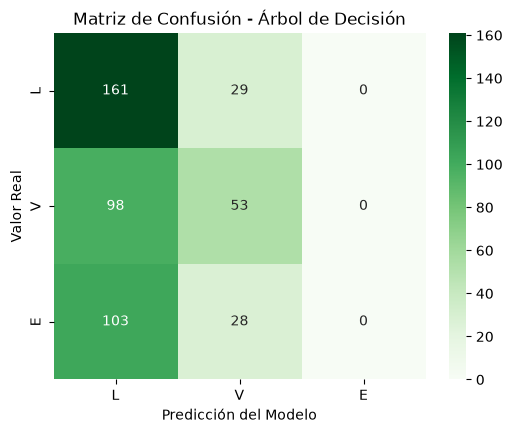

In [345]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generar la matriz usando y_test_encoded y los índices numéricos [0, 1, 2]
cm = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])

# 2. Si definiste un LabelEncoder llamado 'le', podemos obtener el orden exacto de las clases:
# etiquetas_visibles = le.classes_  # Ejemplo: ['E', 'L', 'V']
# O si prefieres forzar el texto fijo en ese orden:
etiquetas_visibles = ["L", "V", "E"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=etiquetas_visibles,
    yticklabels=etiquetas_visibles,
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

Se verifica que la clase 2 "Hay empate" tiene precision y recall 0. Esto puede deberse a:

- Desbalance severo de clases: La clase con 0 accuracy representa un porcentaje muy pequeño del conjunto de datos y el árbol la ignora para maximizar el accuracy global.

- El árbol está sobreajustado o simplificado en exceso: Los parámetros por defecto dejan que el árbol crezca tanto que memoriza el ruido de las clases mayoritarias, o está tan podado (max_depth muy bajo) que elimina ramas de clases minoritarias.

- Métrica de optimización incorrecta: Estás usando accuracy como criterio de optimización, el cual prioriza a las clases con más muestras.

Se propone balancear el peso de las clases utilizando el argumento class_weight='balanced', esto le da más importancia (penalización) a los errores cometidos en las clases con menos muestras. 

In [346]:
# IMPLEMENTACIÓN DEL ÁRBOL DE DECISIÓN CON GANANCIA MÍNIMA DE INFORMACIÓN
# Y DATOS BALANCEADOS


from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Defina el valor de la ganancia mínima de información deseada
min_info_gain = 0.01

# Inicializar el Árbol de Decisión:
# - criterion='entropy': calcula la Ganancia de Información (Information Gain)
# - min_impurity_decrease=min_info_gain: detiene la división cuando la ganancia es menor al valor especificado
arbol_modelo = DecisionTreeClassifier(class_weight="balanced",
    criterion="entropy", min_impurity_decrease=min_info_gain, random_state=42
)

# Entrenar el modelo
arbol_modelo.fit(X_train_encoded, y_train_encoded)

# ==============================================================================
# EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE PRUEBA
# ==============================================================================
y_pred = arbol_modelo.predict(X_test_encoded)

print(
    f"=== Árbol de Decisión (min_info_gain = {min_info_gain}) ==="
)
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred))


=== Árbol de Decisión (min_info_gain = 0.01) ===
Exactitud (Accuracy): 0.3983

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.21      0.33       190
           1       0.48      0.35      0.41       151
           2       0.31      0.73      0.43       131

    accuracy                           0.40       472
   macro avg       0.52      0.43      0.39       472
weighted avg       0.55      0.40      0.38       472



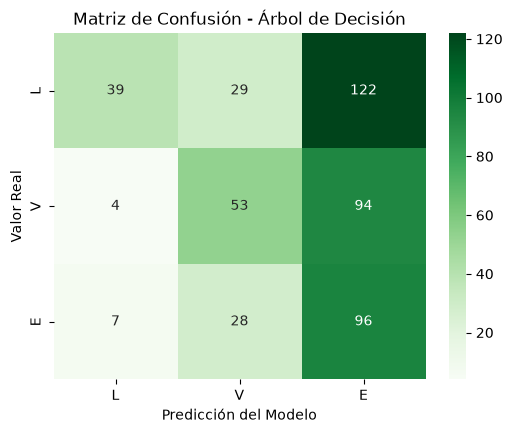

In [347]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generar la matriz usando y_test_encoded y los índices numéricos [0, 1, 2]
cm = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])

# 2. Si definiste un LabelEncoder llamado 'le', podemos obtener el orden exacto de las clases:
# etiquetas_visibles = le.classes_  # Ejemplo: ['E', 'L', 'V']
# O si prefieres forzar el texto fijo en ese orden:
etiquetas_visibles = ["L", "V", "E"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=etiquetas_visibles,
    yticklabels=etiquetas_visibles,
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

=== Naive Bayes (m = 1.0) ===
Exactitud (Accuracy): 0.4449

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.49      0.60      0.54       190
           1       0.39      0.58      0.47       151
           2       0.50      0.07      0.12       131

    accuracy                           0.44       472
   macro avg       0.46      0.41      0.38       472
weighted avg       0.46      0.44      0.40       472



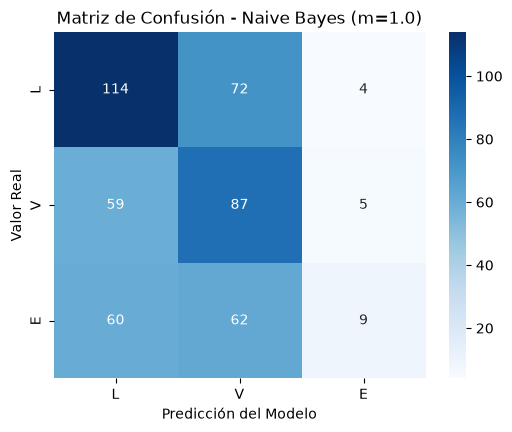

In [348]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# ==============================================================================
# IMPLEMENTACIÓN DE NAIVE BAYES (m-estimate)
# ==============================================================================

# 1. Definir el hiperparámetro m (tamaño equivalente de muestra)
m_param = 1.0

# Para CategoricalNB, alpha corresponde al suavizado de Laplace.
# Si consideramos p uniforme, ajustamos alpha = m_param
nb_modelo = CategoricalNB(alpha=m_param)

# 2. Entrenar el modelo
# Nota: CategoricalNB requiere datos de entrada categóricos discretos/codificados
nb_modelo.fit(X_train_encoded, y_train_encoded)

# 3. Predicción
y_pred_nb = nb_modelo.predict(X_test_encoded)

# ==============================================================================
# EVALUACIÓN DEL MODELO
# ==============================================================================
print(f"=== Naive Bayes (m = {m_param}) ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred_nb):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred_nb))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test_encoded, y_pred_nb, labels=[0, 1, 2])

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["L", "V", "E"],
    yticklabels=["L", "V", "E"],
)
plt.title(f"Matriz de Confusión - Naive Bayes (m={m_param})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

IMPLEMENTACION DEL CLASIFICADOR BASE


In [349]:
#IMPLEMENTACION DEL CLASIFICADOR BASE

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin


class Historico10AniosClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.win_ratios = {}
        self.clase_mayoritaria = 0

    def fit(self, X, y):
        # 1. Determinar la clase mayoritaria global
        uniques, counts = np.unique(y, return_counts=True)
        self.clase_mayoritaria = uniques[np.argmax(counts)]

        # 2. Reconstruir DataFrame auxiliar con las características necesarias
        df = X.copy()
        df["ganador"] = y

        # 3. Filtrar los últimos 10 años presentes en Train
        max_year = df["year"].max()
        df_10y = df[df["year"] >= (max_year - 10)]

        # 4. Calcular partidos jugados y ganados por equipo
        equipos = set(df_10y["home"]).union(set(df_10y["away"]))
        stats = {
            eq: {"jugados": 0, "ganados": 0} for eq in equipos if pd.notna(eq)
        }

        for _, row in df_10y.iterrows():
            h, a, res = row["home"], row["away"], row["ganador"]

            if h in stats:
                stats[h]["jugados"] += 1
                # Si el equipo local ganó (res puede ser 'L' o su versión codificada 0/1/2)
                if res in ["L", 0]:
                    stats[h]["ganados"] += 1

            if a in stats:
                stats[a]["jugados"] += 1
                # Si el equipo visitante ganó
                if res in ["V", 1]:
                    stats[a]["ganados"] += 1

        # 5. Calcular la proporción de victorias por equipo
        for eq, dat in stats.items():
            self.win_ratios[eq] = (
                dat["ganados"] / dat["jugados"] if dat["jugados"] > 0 else 0.0
            )

        return self

    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            h_ratio = self.win_ratios.get(row["home"], 0.0)
            a_ratio = self.win_ratios.get(row["away"], 0.0)

            # Si el local tiene mayor proporción de victorias -> Predice 'L' (o 0)
            if h_ratio > a_ratio:
                predictions.append(0)
            # Si el visitante tiene mayor proporción -> Predice 'V' (o 1)
            elif a_ratio > h_ratio:
                predictions.append(1)
            # Empate técnico de historial -> Predice la clase mayoritaria del dataset
            else:
                predictions.append(self.clase_mayoritaria)

        return np.array(predictions)

Modelo: Clasificador Base (Histórico 10 años)
Accuracy: 0.4725

              precision    recall  f1-score   support

           0       0.52      0.65      0.58       190
           1       0.42      0.66      0.52       151
           2       0.00      0.00      0.00       131

    accuracy                           0.47       472
   macro avg       0.31      0.44      0.36       472
weighted avg       0.34      0.47      0.40       472

Modelo: Árbol de Decisión (sklearn)
Accuracy: 0.3983

              precision    recall  f1-score   support

           0       0.78      0.21      0.33       190
           1       0.48      0.35      0.41       151
           2       0.31      0.73      0.43       131

    accuracy                           0.40       472
   macro avg       0.52      0.43      0.39       472
weighted avg       0.55      0.40      0.38       472



c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucia\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Modelo: Árbol de Decisión (Manual)
Accuracy: 0.4703

              precision    recall  f1-score   support

           0       0.45      0.87      0.60       190
           1       0.54      0.38      0.44       151
           2       0.00      0.00      0.00       131

    accuracy                           0.47       472
   macro avg       0.33      0.42      0.35       472
weighted avg       0.36      0.47      0.38       472

Modelo: Naive Bayes (CategoricalNB)
Accuracy: 0.4449

              precision    recall  f1-score   support

           0       0.49      0.60      0.54       190
           1       0.39      0.58      0.47       151
           2       0.50      0.07      0.12       131

    accuracy                           0.44       472
   macro avg       0.46      0.41      0.38       472
weighted avg       0.46      0.44      0.40       472

Modelo: Random Forest
Accuracy: 0.4237

              precision    recall  f1-score   support

           0       0.45      0.61   

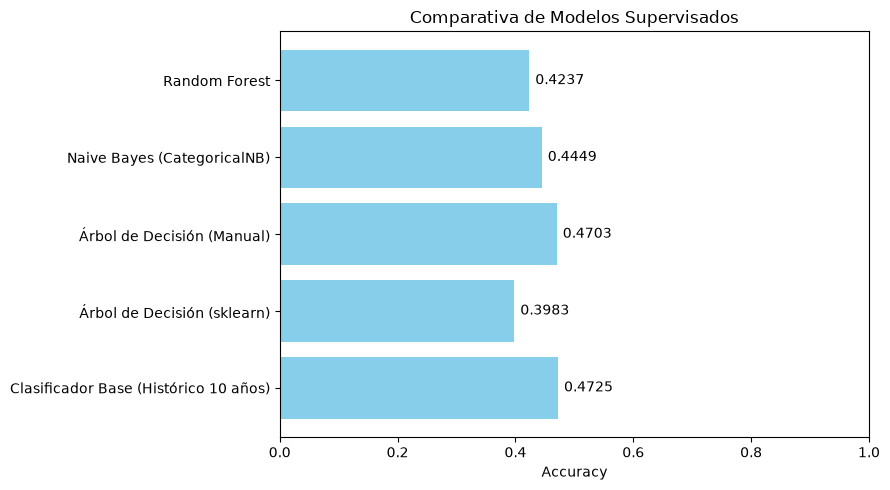

In [350]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# 1. Diccionario actualizado con el Árbol Manual
modelos = {
    "Clasificador Base (Histórico 10 años)": Historico10AniosClassifier(),
    "Árbol de Decisión (sklearn)": DecisionTreeClassifier(
        criterion="entropy",
        class_weight="balanced",
        min_impurity_decrease=0.01,
        random_state=42,
    ),
    "Árbol de Decisión (Manual)": ArbolDecisionManual(
        min_info_gain=0.01, max_depth=5
    ),  # 👈 Árbol Manual
    "Naive Bayes (CategoricalNB)": CategoricalNB(alpha=1.0),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
}

resultados = {}

# 2. Entrenar y evaluar cada modelo
for nombre, model in modelos.items():
    if nombre == "Clasificador Base (Histórico 10 años)":
        # El clasificador base necesita las columnas sin codificar (incluyendo 'year')
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)
    else:
        # Para los modelos de Scikit-Learn y el Árbol Manual, filtramos 'year'


        X_tr_scikit = X_train_encoded
        X_te_scikit = X_test_encoded

        # Entrenar y predecir sobre las matrices sin la variable 'year'
        model.fit(X_tr_scikit, y_train_encoded)
        y_pred = model.predict(X_te_scikit)

    acc = accuracy_score(y_test_encoded, y_pred)
    resultados[nombre] = acc

    print(f"==================================================")
    print(f"Modelo: {nombre}")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test_encoded, y_pred))

# 3. Visualización comparativa de Accuracy
plt.figure(figsize=(9, 5))
bars = plt.barh(
    list(resultados.keys()), list(resultados.values()), color="skyblue"
)
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Comparativa de Modelos Supervisados")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
    )

plt.tight_layout()
plt.show()

# 3. EXPERIMENTACIÓN

- Si modelo base ya está en parte 2, no se agrega, no? Quizás imprimir de nuevo matriz de confusión y/o métricas
- Tunear mejor hiperparámetros
- Agregar hiperparámetros a NB?
- Falta features selection
- Falta graficar error según valores de cada hiperparámetro
- PAra resultados de test faltan: todas las otras métricas (precisión, recall, F1 por clase y macro-F1) y matrices de confusión

In [279]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Listas a las columnas del dataset que usaremos como predictoras
numeric_features = [ 'year', 'month', 'dayofweek', 'is_weekend']
categorical_features = ['home', 'away', 'full_time']

all_features = numeric_features + categorical_features

# Pipeline para los atributos categóricos
pipeline_arbol = Pipeline([
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Aplicamos un pipeline diferente a cada grupo de columnas
preprocessing_arbol = ColumnTransformer([
    ('numeric', 'passthrough', numeric_features),
    ('categorical', pipeline_arbol, categorical_features)
])

preprocessing_nb = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Pipeline inicial, luego se sobreescribe con los modelos definidos en param_grid
pipeline = Pipeline([
    ('preprocessing', 'passthrough'),
    ('model', 'passthrough')
])

# Hiperparámetros del preprocesamiento y del modelo
param_grid = [

    #### Arbol
    {
        'preprocessing': [preprocessing_arbol],
        'model': [DecisionTreeClassifier(random_state=42)],

        # Preprocesamiento categórico
        'preprocessing__categorical__onehot__drop': [
            None,
            'first'
        ],
        # min_impurity_decrease es min_info_gain
        'model__min_impurity_decrease': [
            0.0,
            0.005,
            0.01,
            0.05
        ],
        'model__max_depth': [
            3,
            5,
            None
        ],
        'model__min_samples_leaf': [
            1,
            10,
            50,
            200
        ]
    },

    ##### NB
    {
        'preprocessing': [preprocessing_nb],
        'model': [CategoricalNB()],

        # alpha es análogo a m
        'model__alpha': [
            0.01, 0.1, 0.5, 1, 2, 5, 10
        ]
    }
]


In [280]:
# Estrategia de cross-validation
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True
)


# # GridSearchCV realiza internamente la validación cruzada
# grid_search.fit(X_train, y_train)


# print("Mejores hiperparámetros:")
# print(grid_search.best_params_)

# print(f"\nMejor accuracy medio: {grid_search.best_score_:.3f}")


# # Evaluación final sobre test
# test_accuracy = grid_search.score(X_test, y_test)
# print(f"Accuracy en test: {test_accuracy:.3f}")

In [281]:
resultados = pd.DataFrame(grid_search.cv_results_)

# Identificar modelo
resultados['modelo'] = resultados['param_model'].apply(
    lambda x: type(x).__name__
)


# Mejor árbol
mejor_arbol = (
    resultados[
        resultados['modelo'] == 'DecisionTreeClassifier'
    ]
    .sort_values('mean_test_score', ascending=False)
    .iloc[0]
)

print("=== MEJOR ÁRBOL ===")
print(
    f"Accuracy medio CV: "
    f"{mejor_arbol['mean_test_score']:.3f}"
)
print("Hiperparámetros:")
print(mejor_arbol['params'])



# Mejor Naive Bayes
mejor_nb = (
    resultados[
        resultados['modelo'] == 'CategoricalNB'
    ]
    .sort_values('mean_test_score', ascending=False)
    .iloc[0]
)

print("\n=== MEJOR CATEGORICAL NB ===")
print(
    f"Accuracy medio CV: "
    f"{mejor_nb['mean_test_score']:.3f}"
)
print("Hiperparámetros:")
print(mejor_nb['params'])

AttributeError: 'GridSearchCV' object has no attribute 'cv_results_'

In [33]:

# Reentrenar mejores modelos


from sklearn.base import clone

mejor_pipeline_arbol = clone(pipeline)
mejor_pipeline_arbol.set_params(**mejor_arbol['params'])
mejor_pipeline_arbol.fit(X_train, y_train)

mejor_pipeline_nb = clone(pipeline)
mejor_pipeline_nb.set_params(**mejor_nb['params'])
mejor_pipeline_nb.fit(X_train, y_train)



# Evaluación sobre test


y_pred_arbol = mejor_pipeline_arbol.predict(X_test)
y_pred_nb = mejor_pipeline_nb.predict(X_test)

print(
    "\nAccuracy test Árbol:",
    accuracy_score(y_test, y_pred_arbol)
)

print(
    "Accuracy test CategoricalNB:",
    accuracy_score(y_test, y_pred_nb)
)


Accuracy test Árbol: 0.4986850756081525
Accuracy test CategoricalNB: 0.47928994082840237


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
